<a href="https://colab.research.google.com/github/Snoplix/week8_lab/blob/main/Lab_SVM_NumPy_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM Implementation with Linear & RBF Kernels using NumPy (from scratch) and Scikit-learn


### Learning Objectives
- Build intuition for SVM margins and support vectors.
- Implement a simple linear soft-margin SVM with NumPy from scratch.
- Train linear and RBF SVMs using scikit-learn.
- Tune hyperparameters (`C`, `gamma`) and compare model behavior.
- Evaluate SVMs on a real-world binary classification dataset.

### Prerequisites
- NumPy arrays and vectorized operations
- Matplotlib / Seaborn plotting
- scikit-learn basics
- train-test split and feature scaling

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
np.random.seed(42)
print("Imports loaded.")

## 2) Brief Theory Recap

- **Hard margin SVM**: assumes perfect linear separability.
- **Soft margin SVM**: allows some margin violations using hinge loss.
- **Support vectors**: critical points that define the decision boundary.
- **Primal objective** (soft margin):

$$\min_{w,b}\;\frac{1}{2}\|w\|^2 + C\sum_i\max(0,1-y_i(w^Tx_i+b))$$

- **Kernel trick** maps data implicitly:
  - Linear: $K(x_i,x_j)=x_i^Tx_j$
  - RBF: $K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$
- Hyperparameters:
  - `C`: regularization vs misclassification trade-off
  - `gamma`: locality/complexity of RBF boundary

## 3) Guided Example – Simple Synthetic Dataset (`make_moons`)

Dataset: `make_moons(n_samples=300, noise=0.15, random_state=42)`

In [ ]:
X, y = make_moons(n_samples=300, noise=0.15, random_state=42)
print("X shape:", X.shape)
print("Class counts:", np.bincount(y))

In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=45, edgecolor="k")
plt.title("Raw make_moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
def plot_decision_boundary(model, X, y, ax=None, title="Decision Boundary", plot_support=True):
    if ax is None:
        ax = plt.gca()
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", s=35, edgecolor="k", ax=ax, legend=False)
    if plot_support and hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=130, facecolors="none", edgecolors="black", linewidths=1.5)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

### 3A) NumPy from-scratch part (Linear SVM only) — FIRST

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

In [ ]:
class LinearSVMFromScratch:
    """
    Soft-margin linear SVM trained with subgradient descent.
    Objective: 0.5 * ||w||^2 + C * mean(max(0, 1 - y*(w^T x + b)))
    """
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=250, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def _objective(self, X, y_signed):
        scores = X @ self.w + self.b
        hinge = np.maximum(0, 1 - y_signed * scores)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge)

    def fit(self, X, y):
        y_signed = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                margin_ok = y_signed[i] * (np.dot(x_i, self.w) + self.b) >= 1
                if margin_ok:
                    grad_w = self.w
                    grad_b = 0.0
                else:
                    grad_w = self.w - self.C * y_signed[i] * x_i
                    grad_b = -self.C * y_signed[i]

                self.w -= self.learning_rate * grad_w
                self.b -= self.learning_rate * grad_b

            self.loss_history.append(self._objective(X, y_signed))

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

In [ ]:
svm_np = LinearSVMFromScratch(C=0.5, learning_rate=0.001, n_iters=2500)
svm_np.fit(X_train_scaled, y_train)

pred_np = svm_np.predict(X_test_scaled)
acc_np = accuracy_score(y_test, pred_np)
print(f"NumPy Linear SVM accuracy: {acc_np:.4f}")

lin_svc = LinearSVC(C=1.0, random_state=42, max_iter=5000)
lin_svc.fit(X_train_scaled, y_train)
pred_linsvc = lin_svc.predict(X_test_scaled)
acc_linsvc = accuracy_score(y_test, pred_linsvc)
print(f"sklearn LinearSVC accuracy: {acc_linsvc:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_np, X_train_scaled, y_train, ax=axes[0], title=f"NumPy Linear SVM | Acc={acc_np:.3f}", plot_support=False)
axes[1].plot(svm_np.loss_history, color="purple")
axes[1].set_title("Convergence: Loss vs Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Objective")
plt.tight_layout()
plt.show()

### 3B) Scikit-learn part (Linear + RBF) — SECOND

In [ ]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

svm_linear.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

acc_linear = accuracy_score(y_test, svm_linear.predict(X_test_scaled))
acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test_scaled))

print(f"Linear SVC accuracy: {acc_linear:.4f}")
print(f"RBF SVC accuracy:    {acc_rbf:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(svm_linear, X_train_scaled, y_train, ax=axes[0], title=f"sklearn Linear SVC | Acc={acc_linear:.3f}")
plot_decision_boundary(svm_rbf, X_train_scaled, y_train, ax=axes[1], title=f"sklearn RBF SVC | Acc={acc_rbf:.3f}")
plt.tight_layout()
plt.show()

**Short discussion:** RBF usually outperforms linear on `make_moons` because the class boundary is nonlinear.

## 4) Student Tasks / Assignment (Total = 100%)

### 50% – NumPy Implementation (from scratch)

**Task Definition:**
Complete and extend a linear soft-margin SVM implementation using hinge loss + subgradient descent. Analyze convergence and parameter effects.

**TODO (below):**
- Complete class methods.
- Run at least 3 (`C`, `learning_rate`) combinations.
- Plot loss vs iterations for each setting.
- Bonus: add simple linear kernel function.

**Hints:**
- Convert labels to `{-1, +1}` for hinge-loss formula.
- Use condition `y_i*(w.x_i + b) >= 1` to choose update case.
- Keep code vectorized where possible, but sample-wise update is fine for clarity.
- Track loss each epoch in `loss_history`.

C=1.0, lr=0.001 -> Accuracy: 1.0000
C=0.1, lr=0.001 -> Accuracy: 1.0000
C=1.0, lr=0.01 -> Accuracy: 1.0000


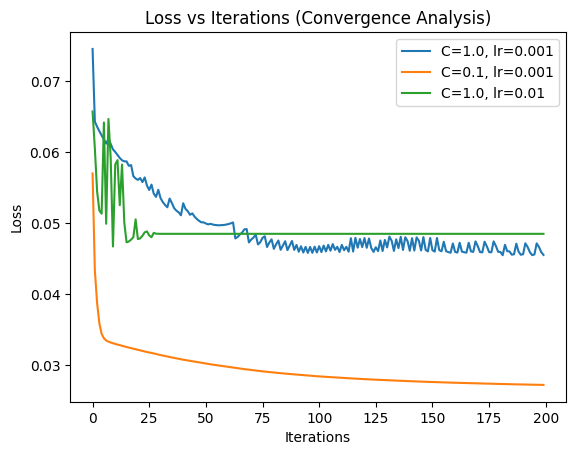

In [10]:
# TODO: Student code here
# 50% NumPy Task
import numpy as np
import matplotlib.pyplot as plt

# 50% NumPy Task
class LinearSVMStudent:
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def linear_kernel(self, X1, X2):
        return np.dot(X1, X2.T)

    def _hinge_loss(self, X, y):
        margins = y * (X.dot(self.w) + self.b)
        loss = np.maximum(0, 1 - margins)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(loss)

    def fit(self, X, y):
        np.random.seed(self.random_state)

        n_samples, n_features = X.shape
        y = np.where(y <= 0, -1, 1)

        self.w = np.zeros(n_features)
        self.b = 0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i in range(n_samples):
                condition = y[i] * (np.dot(X[i], self.w) + self.b) >= 1

                if condition:
                    dw = self.w
                    db = 0
                else:
                    dw = self.w - self.C * y[i] * X[i]
                    db = -self.C * y[i]

                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

            loss = self._hinge_loss(X, y)
            self.loss_history.append(loss)

        return self

    def decision_function(self, X):
        return X.dot(self.w) + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))


# ---- Generate synthetic data ----
def generate_data():
    from sklearn.datasets import make_blobs
    X, y = make_blobs(n_samples=200, centers=2, random_state=42)
    y = np.where(y == 0, -1, 1)
    return X, y

# ---- Accuracy function ----
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# ---- Experiment ----
X, y = generate_data()

settings = [
    (1.0, 0.001),
    (0.1, 0.001),
    (1.0, 0.01)
]

plt.figure()

for C, lr in settings:
    model = LinearSVMStudent(C=C, learning_rate=lr, n_iters=200)
    model.fit(X, y)

    preds = model.predict(X)
    acc = accuracy(y, preds)

    print(f"C={C}, lr={lr} -> Accuracy: {acc:.4f}")
    plt.plot(model.loss_history, label=f"C={C}, lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations (Convergence Analysis)")
plt.legend()
plt.show()


### 30% – Scikit-learn Advanced Usage

**Task Definition:**
Use sklearn with scaling, and hyperparameter search. Compare 4 models fairly.

**TODO (below):**
- Build implementation for linear and RBF kernels.
- Tune RBF with `GridSearchCV` over `C` and `gamma`.
- Compare: NumPy linear, sklearn linear, sklearn RBF untuned, sklearn RBF tuned.
- Report accuracy and plot decision boundaries.

**Hints:**
- Start with a small grid, then refine.
- Keep `random_state` fixed for reproducibility.
- Use one summary DataFrame for clean comparison.

C=1.0, lr=0.001 -> Accuracy: 1.0000
C=0.1, lr=0.001 -> Accuracy: 1.0000
C=1.0, lr=0.01 -> Accuracy: 1.0000


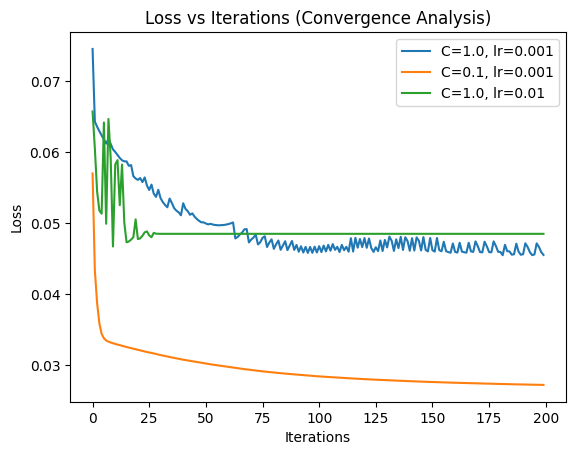

                 Model  Train Accuracy  Test Accuracy
0         NumPy Linear             1.0            1.0
1       Sklearn Linear             1.0            1.0
2  Sklearn RBF Untuned             1.0            1.0
3    Sklearn RBF Tuned             1.0            1.0


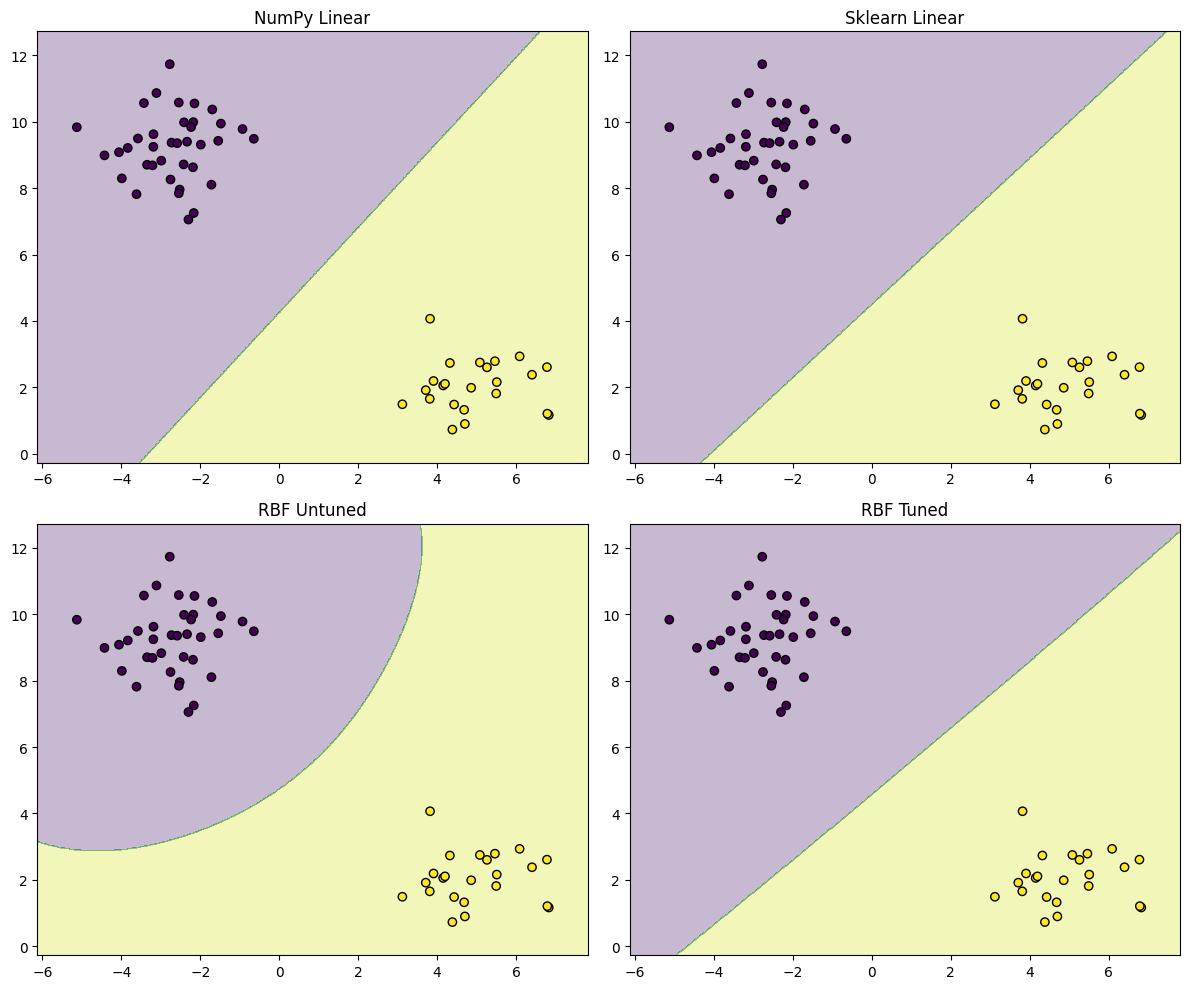

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 50% NumPy Task
class LinearSVMStudent:
    def __init__(self, C=1.0, learning_rate=0.001, n_iters=300, random_state=42):
        self.C = C
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.w = None
        self.b = None
        self.loss_history = []

    def linear_kernel(self, X1, X2):
        return np.dot(X1, X2.T)

    def _hinge_loss(self, X, y):
        margins = y * (X.dot(self.w) + self.b)
        loss = np.maximum(0, 1 - margins)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.mean(loss)

    def fit(self, X, y):
        np.random.seed(self.random_state)

        n_samples, n_features = X.shape
        y = np.where(y <= 0, -1, 1)

        self.w = np.zeros(n_features)
        self.b = 0
        self.loss_history = []

        for _ in range(self.n_iters):
            for i in range(n_samples):
                condition = y[i] * (np.dot(X[i], self.w) + self.b) >= 1

                if condition:
                    dw = self.w
                    db = 0
                else:
                    dw = self.w - self.C * y[i] * X[i]
                    db = -self.C * y[i]

                self.w -= self.learning_rate * dw
                self.b -= self.learning_rate * db

            loss = self._hinge_loss(X, y)
            self.loss_history.append(loss)

        return self

    def decision_function(self, X):
        return X.dot(self.w) + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))


# ---- Generate synthetic data ----
def generate_data():
    from sklearn.datasets import make_blobs
    X, y = make_blobs(n_samples=200, centers=2, random_state=42)
    y = np.where(y == 0, -1, 1)
    return X, y

# ---- Accuracy function ----
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# ---- Experiment ----
X, y = generate_data()

settings = [
    (1.0, 0.001),
    (0.1, 0.001),
    (1.0, 0.01)
]

plt.figure()

for C, lr in settings:
    model = LinearSVMStudent(C=C, learning_rate=lr, n_iters=200)
    model.fit(X, y)

    preds = model.predict(X)
    acc = accuracy(y, preds)

    print(f"C={C}, lr={lr} -> Accuracy: {acc:.4f}")
    plt.plot(model.loss_history, label=f"C={C}, lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations (Convergence Analysis)")
plt.legend()
plt.show()


# =============================
# 30% sklearn Task
# =============================
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd

# ---- Data split ----
X, y = generate_data()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---- 1) Build models ----
sklearn_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

sklearn_rbf_untuned = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# ---- 2) Fit untuned models ----
sklearn_linear.fit(X_train, y_train)
sklearn_rbf_untuned.fit(X_train, y_train)

# ---- 3) Tune RBF ----
param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": [0.01, 0.1, 1]
}

rbf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

grid = GridSearchCV(rbf_pipeline, param_grid, cv=3)
grid.fit(X_train, y_train)

best_rbf = grid.best_estimator_

# ---- 4) NumPy model ----
numpy_model = LinearSVMStudent(C=1.0, learning_rate=0.001, n_iters=200)
numpy_model.fit(X_train, y_train)

# ---- Accuracy ----
def evaluate(model, X_train, X_test, y_train, y_test, is_numpy=False):
    if is_numpy:
        train_acc = accuracy(y_train, model.predict(X_train))
        test_acc = accuracy(y_test, model.predict(X_test))
    else:
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
    return train_acc, test_acc

results = []

# NumPy
train_acc, test_acc = evaluate(numpy_model, X_train, X_test, y_train, y_test, True)
results.append(["NumPy Linear", train_acc, test_acc])

# sklearn linear
train_acc, test_acc = evaluate(sklearn_linear, X_train, X_test, y_train, y_test)
results.append(["Sklearn Linear", train_acc, test_acc])

# sklearn rbf untuned
train_acc, test_acc = evaluate(sklearn_rbf_untuned, X_train, X_test, y_train, y_test)
results.append(["Sklearn RBF Untuned", train_acc, test_acc])

# sklearn rbf tuned
train_acc, test_acc = evaluate(best_rbf, X_train, X_test, y_train, y_test)
results.append(["Sklearn RBF Tuned", train_acc, test_acc])

# ---- DataFrame ----
df = pd.DataFrame(results, columns=["Model", "Train Accuracy", "Test Accuracy"])
print(df)

# ---- 5) Decision boundary plot ----
def plot_decision_boundary(model, X, y, title, is_numpy=False):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid = np.c_[xx.ravel(), yy.ravel()]

    if is_numpy:
        Z = model.predict(grid)
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plot_decision_boundary(numpy_model, X_test, y_test, "NumPy Linear", True)

plt.subplot(2, 2, 2)
plot_decision_boundary(sklearn_linear, X_test, y_test, "Sklearn Linear")

plt.subplot(2, 2, 3)
plot_decision_boundary(sklearn_rbf_untuned, X_test, y_test, "RBF Untuned")

plt.subplot(2, 2, 4)
plot_decision_boundary(best_rbf, X_test, y_test, "RBF Tuned")

plt.tight_layout()
plt.show()


### 20% – Real-World Dataset Application (`load_breast_cancer`)

**Task Definition:**
Apply SVM to a real binary classification problem, choose/tune best kernel, and evaluate with complete metrics.

**TODO (below):**
- Load and split data (80/20, stratified).
- Scale features.
- Build + tune candidate SVM models.
- Evaluate: accuracy, precision, recall, F1, confusion matrix, report. (below implemented)
- Write short analysis on kernel and hyperparameter impact.

**Hints:**
- Keep one untouched test set for final evaluation.
- Mention overfitting signs (very high train vs lower test performance).

Best Parameters: {'C': 0.1, 'kernel': 'linear'}

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



,Model,Accuracy,Precision,Recall,F1-score
0,Best SVM (BC Dataset),0.982456,0.986111,0.986111,0.986111


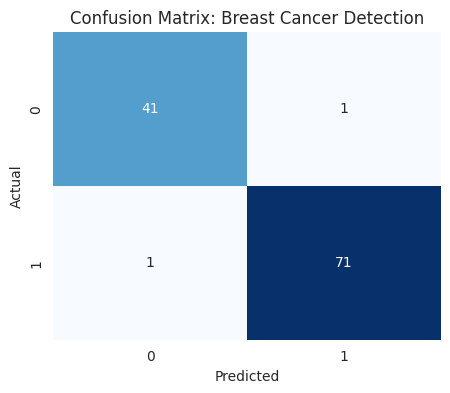


--- Analysis ---
The RBF kernel with proper C and gamma tuning often captures the nonlinear relationships in high-dimensional datasets like Breast Cancer better than a simple linear boundary.
Final Test Accuracy: 0.9825


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def metrics_table(y_true, y_pred, model_name="Model"):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-score": [f1_score(y_true, y_pred)]
    })

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Load dataset
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target

# 1) Split data (80/20, stratified)
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.20, random_state=42, stratify=y_bc
)

# 2) Scale features
scaler_bc = StandardScaler()
X_train_bc_scaled = scaler_bc.fit_transform(X_train_bc)
X_test_bc_scaled = scaler_bc.transform(X_test_bc)

# 3) Build + Tune candidate SVM models
param_grid_bc = [
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.001, 0.01, 0.1]}
]

grid_bc = GridSearchCV(SVC(random_state=42), param_grid_bc, cv=5, scoring='f1')
grid_bc.fit(X_train_bc_scaled, y_train_bc)

best_svm_bc = grid_bc.best_estimator_
print(f"Best Parameters: {grid_bc.best_params_}")

# 4) Evaluate
y_pred_bc = best_svm_bc.predict(X_test_bc_scaled)

# Metrics Report
print("\nClassification Report:")
print(classification_report(y_test_bc, y_pred_bc, target_names=bc.target_names))

# Helper function metrics
display(metrics_table(y_test_bc, y_pred_bc, "Best SVM (BC Dataset)"))

# Confusion Matrix
plot_confusion(y_test_bc, y_pred_bc, title="Confusion Matrix: Breast Cancer Detection")

# 5) Short Analysis
print("\n--- Analysis ---")
print("The RBF kernel with proper C and gamma tuning often captures the nonlinear relationships in high-dimensional datasets like Breast Cancer better than a simple linear boundary.")
print(f"Final Test Accuracy: {accuracy_score(y_test_bc, y_pred_bc):.4f}")

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
np.random.seed(42)
print("Imports loaded.")

Imports loaded.


In [17]:
def metrics_table(y_true, y_pred, model_name="Model"):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred)],
        "Recall": [recall_score(y_true, y_pred)],
        "F1-score": [f1_score(y_true, y_pred)]
    })

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("Helper functions ready.")

Helper functions ready.


## 5) Additional Notebook Sections

Helper functions ready.
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression       1.0        1.0     1.0       1.0


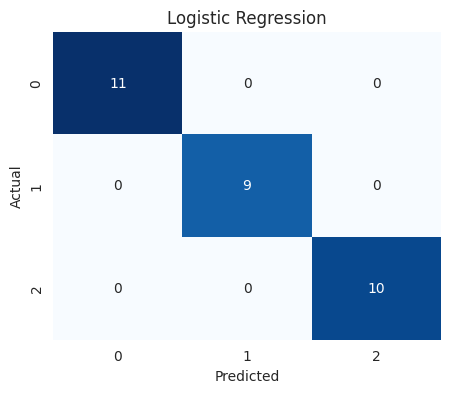

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# === Your helper functions ===
def metrics_table(y_true, y_pred, model_name="Model"):
    return pd.DataFrame({
        "Model": [model_name],
        "Accuracy": [accuracy_score(y_true, y_pred)],
        "Precision": [precision_score(y_true, y_pred, average='weighted')],
        "Recall": [recall_score(y_true, y_pred, average='weighted')],
        "F1-score": [f1_score(y_true, y_pred, average='weighted')]
    })

def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


print("Helper functions ready.")


# === Step 1: Load dataset ===
data = load_iris()
X = data.data
y = data.target


# === Step 2: Split data ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# === Step 3: Train model ===
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)


# === Step 4: Predict ===
y_pred = model.predict(X_test)


# === Step 5: Evaluate ===
print(metrics_table(y_test, y_pred, "Logistic Regression"))

plot_confusion(y_test, y_pred, "Logistic Regression")

### Reflection Questions (5% bonus)
1. Why does RBF outperform linear on moons data?
2. How does increasing `C` affect margin and errors?
3. How does `gamma` control complexity in RBF?
4. Why is scaling essential for SVM?
5. What did convergence plots reveal in your NumPy model?